## Lab 8

In this assignment you will investigate the claim that in the case of data whrere the classes are very close (or slightly overlapping), a support vector classifier with a small value of C that misclassifies a couple of training observations may perform better on test data than one with a huge value of C that does not misclassify any training observations.

In [ ]:
# Import your libraries here
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score

**(a) Generate two-class data with p = 2 in such a way that the classes are slightly overlapping.**

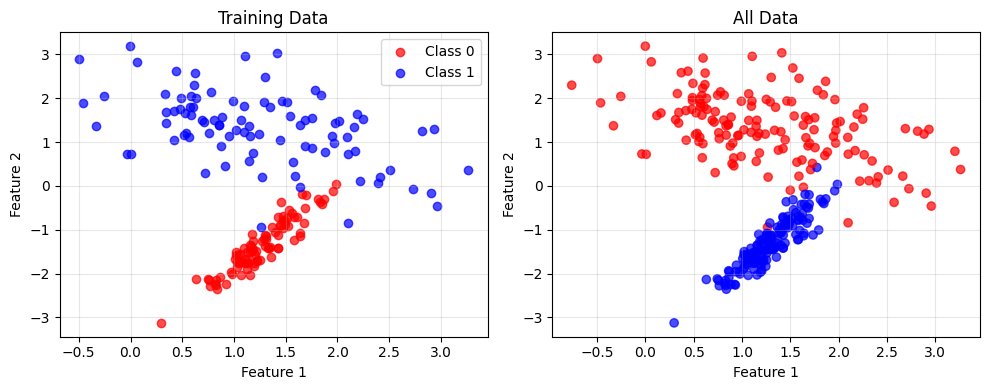

Training set size: 180
Temporary set size: 120


In [2]:
np.random.seed(42)

X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.3,
    flip_y=0.0,
    random_state=42,
)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c='red', alpha=0.7, label='Class 0')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='blue', alpha=0.7, label='Class 1')
plt.title('Training Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.title('All Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training set size: {X_train.shape[0]}")
print(f"Temporary set size: {X_temp.shape[0]}")

**(b) Compute the cross-validation error rates for support vector classifiers with a range of C values. How many training observations are misclassified for each value of C considered, and how does this relate to the cross-validation errors obtained?**

C Value | Training Errors | Misclassified | CV Error Rate
-------------------------------------------------------
  0.010 |          0.0389 |            7 |        0.0333
  0.100 |          0.0278 |            5 |        0.0333
  1.000 |          0.0222 |            4 |        0.0556
 10.000 |          0.0222 |            4 |        0.0333
100.000 |          0.0278 |            5 |        0.0278


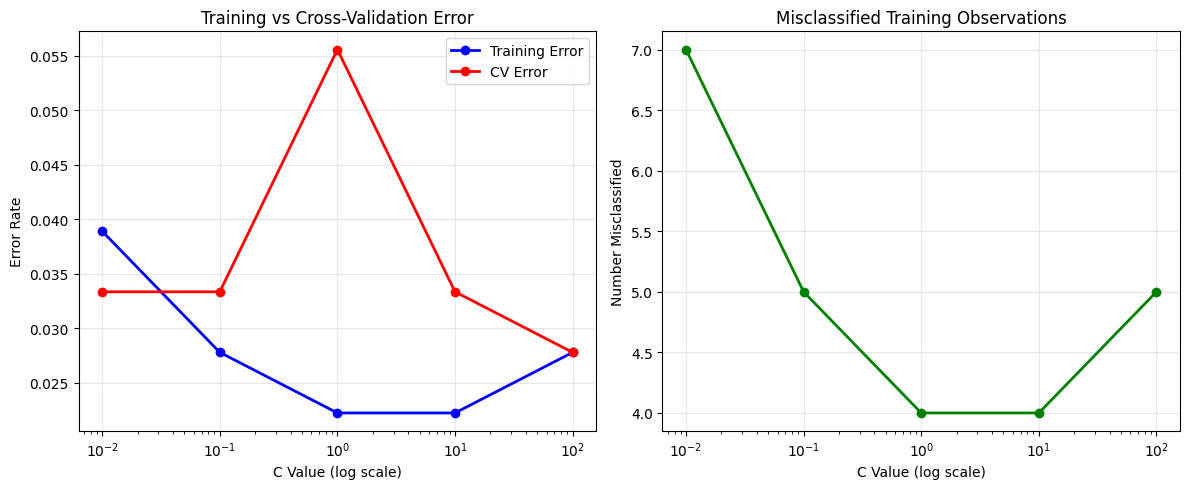

In [3]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

C_values = [0.01, 0.1, 1, 10, 100]

cv_errors = []
training_errors = []
misclassified_counts = []

print("C Value | Training Errors | Misclassified | CV Error Rate")
print("-------------------------------------------------------")

for C in C_values:
    svm = SVC(C=C, kernel='linear', random_state=42)
    
    svm.fit(X_train, y_train)
    
    y_train_pred = svm.predict(X_train)
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    training_errors.append(train_error)
    
    misclassified = np.sum(y_train != y_train_pred)
    misclassified_counts.append(misclassified)
    
    cv_scores = cross_val_score(svm, X_train, y_train, cv=5, scoring='accuracy')
    cv_error = 1 - np.mean(cv_scores)
    cv_errors.append(cv_error)
    
    print(f"{C:7.3f} | {train_error:15.4f} | {misclassified:12d} | {cv_error:13.4f}")


# Plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogx(C_values, training_errors, 'bo-', label='Training Error', linewidth=2)
plt.semilogx(C_values, cv_errors, 'ro-', label='CV Error', linewidth=2)
plt.xlabel('C Value (log scale)')
plt.ylabel('Error Rate')
plt.title('Training vs Cross-Validation Error')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(C_values, misclassified_counts, 'go-', linewidth=2)
plt.xlabel('C Value (log scale)')
plt.ylabel('Number Misclassified')
plt.title('Misclassified Training Observations')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**(c) Generate an appropriate test data set, and compute the test errors corresponding to each of the values of C considered. Which value of C leads to the fewest test errors, and how does this compare to the values of C that yield the fewest training errors and the fewest cross-validation errors?**

C Value | Test Error | Training Error | CV Error
--------------------------------------------------
  0.010 |     0.0167 |        0.0389 |    0.0333
  0.100 |     0.0167 |        0.0278 |    0.0333
  1.000 |     0.0000 |        0.0222 |    0.0556
 10.000 |     0.0167 |        0.0222 |    0.0333
100.000 |     0.0167 |        0.0278 |    0.0278

Best C for training error: 1 (error: 0.0222)
Best C for CV error: 100 (error: 0.0278)
Best C for test error: 1 (error: 0.0000)


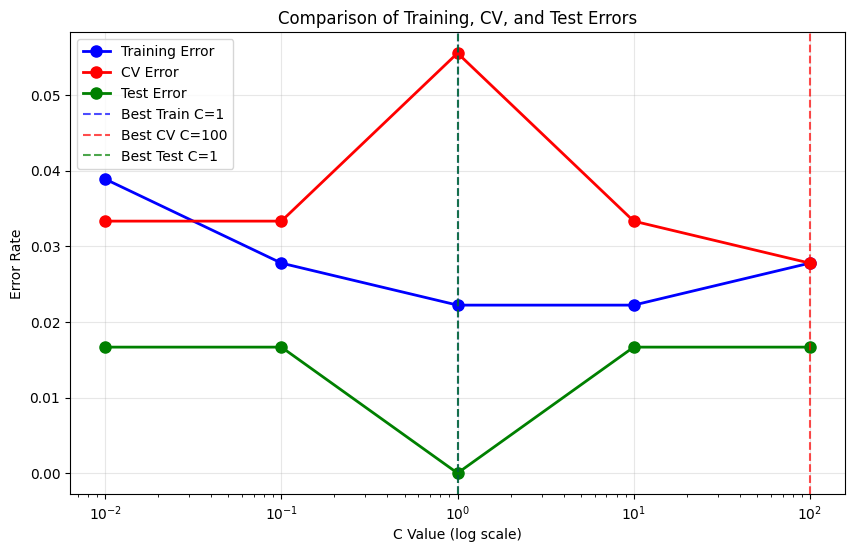

In [4]:
test_errors = []
best_train_C = C_values[np.argmin(training_errors)]
best_cv_C = C_values[np.argmin(cv_errors)]

print("C Value | Test Error | Training Error | CV Error")
print("-" * 50)

for i, C in enumerate(C_values):
    svm = SVC(C=C, kernel='linear', random_state=42)
    svm.fit(X_train, y_train)
    
    y_test_pred = svm.predict(X_test)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    test_errors.append(test_error)
    
    print(f"{C:7.3f} | {test_error:10.4f} | {training_errors[i]:13.4f} | {cv_errors[i]:9.4f}")

best_test_C = C_values[np.argmin(test_errors)]
best_train_C = C_values[np.argmin(training_errors)]
best_cv_C = C_values[np.argmin(cv_errors)]

print(f"\nBest C for training error: {best_train_C} (error: {min(training_errors):.4f})")
print(f"Best C for CV error: {best_cv_C} (error: {min(cv_errors):.4f})")
print(f"Best C for test error: {best_test_C} (error: {min(test_errors):.4f})")

# Plot
plt.figure(figsize=(10, 6))
plt.semilogx(C_values, training_errors, 'bo-', label='Training Error', linewidth=2, markersize=8)
plt.semilogx(C_values, cv_errors, 'ro-', label='CV Error', linewidth=2, markersize=8)
plt.semilogx(C_values, test_errors, 'go-', label='Test Error', linewidth=2, markersize=8)

plt.axvline(best_train_C, color='blue', linestyle='--', alpha=0.7, label=f'Best Train C={best_train_C}')
plt.axvline(best_cv_C, color='red', linestyle='--', alpha=0.7, label=f'Best CV C={best_cv_C}')
plt.axvline(best_test_C, color='green', linestyle='--', alpha=0.7, label=f'Best Test C={best_test_C}')

plt.xlabel('C Value (log scale)')
plt.ylabel('Error Rate')
plt.title('Comparison of Training, CV, and Test Errors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**(d) Discuss your results.**

Because the classes were generated with slight overlap, perfect separation is not achievable without massive amounts of overfitting. This is shown in the training error curve: as C increases, the training error decreases, but the validation error(CV error) does not continue to improve. Instead the CV error is minimized at a moderate C value (C~=1) showing an optimal balance between margin width and flexability. Very small C underfits the data and large C values overfit. The test set accuracy is highest near the same C selected by cross validation, confirming that CV error provides a better estimate of performance than training error. The results illustrate the SVM bias-variance tradeoff and demonstrate why cross validation should guide model selection and not training error.